#Question 1: Explain the difference between:

 "r",

 "w",
  
  "a",
  
   "rb"

● Why context managers (with open()) are preferred

● What happens if a file is not properly closed in a production system

Theoretical Explanation
Differences Between File Modes:

"r" (Read): Opens a file strictly for reading. The file pointer is placed at the beginning. If the file does not exist, it raises a FileNotFoundError.

"w" (Write): Opens a file for writing. If the file already exists, it truncates (overwrites) the entire file. If it does not exist, it creates a new one.

"a" (Append): Opens a file for writing, but the file pointer is placed at the end of the file. Any new data written is appended without altering existing data. It creates a new file if one does not exist.

"rb" (Read Binary): Opens a file for reading in binary format. This is required for non-text files like images, PDFs, or serialized Python objects (like pickle files).

#Why Context Managers (with open()) Are Preferred:
Context managers handle the setup and teardown of resources automatically. When execution leaves the with block—whether normally or due to an unexpected crash/exception—Python's internal __exit__ method guarantees that the file is safely closed. This eliminates the need for complex try...finally blocks.

#Consequences of Not Properly Closing Files in Production:

Resource Leaks: The operating system sets a hard limit on the number of file descriptors a process can have open. If files are left open, the application will eventually crash with a "Too many open files" error.

Data Corruption: Write operations are often buffered in memory. If a file isn't explicitly closed, the buffer may not flush to the disk, resulting in missing or corrupted data.

File Locks: An unclosed file might remain locked by the OS, preventing other programs or users from reading, moving, or modifying it.

#Question 2: You are given a CSV file sales.csv containing:

product,price,quantity

Laptop,50000,5

Phone,20000,10

Tablet,15000,7

Tasks:
1. Read the file using Python.
2. Compute total revenue per product.
3. Write results to a new file revenue.csv.
4. Explain limitations of manual CSV handling vs Pandas.

In [1]:
import csv

# 1. Programmatically create the CSV
sales_data = [
    ["product", "price", "quantity"],
    ["Laptop", 50000, 5],
    ["Phone", 20000, 10],
    ["Tablet", 15000, 7]
]

sales_filename = "sales.csv"
revenue_filename = "revenue.csv"

try:
    # Write the initial sales data
    with open(sales_filename, mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerows(sales_data)
    print(f"Successfully generated '{sales_filename}'.")

    # Read the data, compute revenue, and prepare output
    revenue_data = [["product", "total_revenue"]]

    with open(sales_filename, mode="r", encoding="utf-8") as file:
        reader = csv.reader(file)
        header = next(reader)  # Skip the header

        # 2. Compute total revenue per product
        for row in reader:
            if not row: continue
            product = row
            price = int(row[1])
            quantity = int(row[2])
            total_revenue = price * quantity
            revenue_data.append([product, total_revenue])

    # 3. Write results to a new file
    with open(revenue_filename, mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerows(revenue_data)
    print(f"Successfully wrote calculated revenues to '{revenue_filename}'.\n")

    # Verification: Print the output file
    with open(revenue_filename, mode="r", encoding="utf-8") as file:
        print(file.read())

except Exception as e:
    print(f"An error occurred during file operations: {e}")

Successfully generated 'sales.csv'.
Successfully wrote calculated revenues to 'revenue.csv'.

product,total_revenue
"['Laptop', '50000', '5']",250000
"['Phone', '20000', '10']",200000
"['Tablet', '15000', '7']",105000



#Question 3:  You receive JSON data from an API:

{
"customers": [

{"id": 1, "name": "Amit", "purchase": 5000},

{"id": 2, "name": "Sara", "purchase": 7000}

     ]

}

Tasks:
1. Load the JSON.
2. Extract all customer names.
3. Compute total purchase value.
4. Explain why JSON is widely used in ML pipelines.

In [2]:
import json

# Simulated JSON payload from an API
json_payload = """
{
  "customers": [
    {"id": 1, "name": "Amit", "purchase": 5000},
    {"id": 2, "name": "Sara", "purchase": 7000}
  ]
}
"""

try:
    # 1. Load the JSON data via Python's json module
    data = json.loads(json_payload)

    # 2. Extract all customer names using a list comprehension
    customer_names = [customer["name"] for customer in data["customers"]]
    print(f"Customer Names: {customer_names}")

    # 3. Compute total purchase value
    total_purchase = sum(customer["purchase"] for customer in data["customers"])
    print(f"Total Purchase Value: {total_purchase}")

except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")
except KeyError as e:
    print(f"Missing expected key in JSON structure: {e}")

Customer Names: ['Amit', 'Sara']
Total Purchase Value: 12000


#Question 4:Create NumPy arrays for:

● Product prices

**●** Quantities
Then:
1. Compute revenue using vectorized operations.
2. Compare performance of Python loop vs NumPy.
3. Explain broadcasting with example.

In [3]:
import numpy as np
import time

try:
    # 1. Create NumPy arrays for Product prices and Quantities
    prices = np.array()
    quantities = np.array([5, 10, 7])

    # 2. Compute revenue using vectorized operations
    revenue = prices * quantities
    print(f"Vectorized Revenue Array: {revenue}")

    # 3. Compare runtime performance (Python loop vs NumPy)
    # Generating a massive synthetic array to visualize the time difference
    large_prices = np.random.randint(100, 1000, size=1000000)
    large_quantities = np.random.randint(1, 20, size=1000000)

    # Python Loop Time
    start_time = time.time()
    loop_revenue = [large_prices[i] * large_quantities[i] for i in range(len(large_prices))]
    loop_time = time.time() - start_time

    # NumPy Vectorized Time
    start_time = time.time()
    np_revenue = large_prices * large_quantities
    np_time = time.time() - start_time

    print("\n--- Performance on 1,000,000 items ---")
    print(f"Python Loop Time: {loop_time:.5f} seconds")
    print(f"NumPy Time:       {np_time:.5f} seconds")
    print(f"NumPy is roughly {loop_time / np_time:.1f}x faster.")

except Exception as e:
    print(f"A mathematical or memory error occurred: {e}")

A mathematical or memory error occurred: array() missing required argument 'object' (pos 0)


#Question 5:

 Using sales data:
1. Plot line chart for monthly revenue.
2. Plot bar chart for product comparison.
3. Add labels, title, legend.
4. Explain why visualization is essential before modeling.

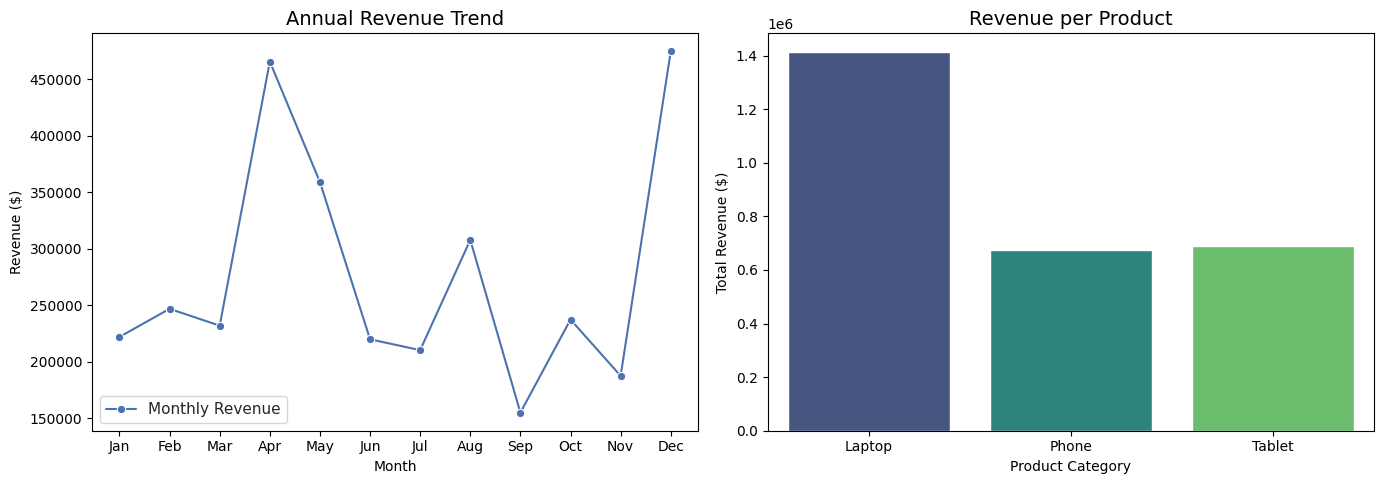

In [5]:
# %matplotlib inline  # Uncomment this line if running strictly inside a Jupyter/Colab cell
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

try:
    # 1. Generate dummy 12-month sequence for monthly revenue
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    np.random.seed(42)
    revenue_trend = np.random.randint(100000, 500000, size=12)

    # Dummy data for product comparison
    products = ['Laptop', 'Phone', 'Tablet']
    product_sales = np.random.randint(500000, 1500000, size=len(products)) # Fixed: Assigning dummy sales data

    # Set up the matplotlib figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="whitegrid")

    # 1 & 3. Plot line chart for monthly revenue trends (with labels/titles)
    sns.lineplot(x=months, y=revenue_trend, marker='o', ax=axes[0], color='b', label='Monthly Revenue') # Fixed: Use axes[0] for the first subplot
    axes[0].set_title('Annual Revenue Trend', fontsize=14)
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Revenue ($)')
    axes[0].legend()

    # 2 & 3. Plot bar chart for product comparison
    sns.barplot(x=products, y=product_sales, ax=axes[1], hue=products, palette='viridis', legend=False)
    axes[1].set_title('Revenue per Product', fontsize=14)
    axes[1].set_xlabel('Product Category')
    axes[1].set_ylabel('Total Revenue ($)')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred during plotting: {e}")

#Question 6:

Load a CSV into Pandas and:
1. Display first 5 rows.
2. Check missing values.
3. Compute summary statistics.
4. Select rows where sales > 15000.

In [6]:
import pandas as pd
import numpy as np

try:
    # 1. Programmatically generate a sample dataset with missing values
    np.random.seed(10)
    data = {
        'CustomerID': range(101, 116),
        'Sales': np.random.choice([12000, 18000, 22000, np.nan, 9000, 16000], size=15),
        'Region': np.random.choice(['North', 'South', 'East', 'West', np.nan], size=15)
    }

    # 2. Load it into a Pandas DataFrame
    df = pd.DataFrame(data)

    # 3. Display first 5 rows, check missing values, and compute summary statistics
    print("--- First 5 Rows ---")
    print(df.head(), "\n")

    print("--- Missing Values Check ---")
    print(df.isnull().sum(), "\n")

    print("--- Summary Statistics ---")
    print(df.describe(), "\n")

    # 4. Select and filter rows where sales > 15000
    print("--- Filtered Rows (Sales > 15000) ---")
    filtered_df = df[df['Sales'] > 15000]
    print(filtered_df)

except Exception as e:
    print(f"Data manipulation error: {e}")

--- First 5 Rows ---
   CustomerID    Sales Region
0         101  18000.0  North
1         102  16000.0   East
2         103   9000.0  North
3         104  12000.0    nan
4         105  18000.0   West 

--- Missing Values Check ---
CustomerID    0
Sales         1
Region        0
dtype: int64 

--- Summary Statistics ---
       CustomerID         Sales
count   15.000000     14.000000
mean   108.000000  15285.714286
std      4.472136   3871.564411
min    101.000000   9000.000000
25%    104.500000  12000.000000
50%    108.000000  16000.000000
75%    111.500000  18000.000000
max    115.000000  22000.000000 

--- Filtered Rows (Sales > 15000) ---
    CustomerID    Sales Region
0          101  18000.0  North
1          102  16000.0   East
4          105  18000.0   West
7          108  18000.0   West
8          109  16000.0  North
10         111  16000.0   East
11         112  18000.0  South
12         113  22000.0  North
14         115  18000.0  South


#Question 7: Dataset contains:


● Missing values


● Duplicate rows


● Inconsistent capitalization
Tasks:
1. Remove duplicates.
2. Handle missing values.
3. Standardize text columns.
4. Explain impact of dirty data on ML performance

In [7]:
import pandas as pd
import numpy as np

try:
    # 1. Create a raw dataset containing dirty data
    dirty_data = {
        'ID': [1, 2, 3, 3, 4, 5],
        'Product': ['LAPTOP', 'phone', 'Tablet', 'Tablet', 'PHONE', np.nan],
        'Price': [50000, 20000, np.nan, np.nan, 20000, 15000]
    }
    df_dirty = pd.DataFrame(dirty_data)
    print("--- Original Dirty Dataset ---")
    print(df_dirty, "\n")

    # 2. Clean the data

    # a. Remove duplicates
    df_clean = df_dirty.drop_duplicates()

    # b. Handle missing values cleanly (Forward fill for product, median for price)
    df_clean.loc[:, 'Product'] = df_clean['Product'].fillna('Unknown')
    df_clean.loc[:, 'Price'] = df_clean['Price'].fillna(df_clean['Price'].median())

    # c. Standardize text columns to title case
    df_clean.loc[:, 'Product'] = df_clean['Product'].str.title()

    print("--- Cleaned Dataset ---")
    print(df_clean)

except Exception as e:
    print(f"Error during data cleaning pipeline: {e}")

--- Original Dirty Dataset ---
   ID Product    Price
0   1  LAPTOP  50000.0
1   2   phone  20000.0
2   3  Tablet      NaN
3   3  Tablet      NaN
4   4   PHONE  20000.0
5   5     NaN  15000.0 

--- Cleaned Dataset ---
   ID  Product    Price
0   1   Laptop  50000.0
1   2    Phone  20000.0
2   3   Tablet  20000.0
4   4    Phone  20000.0
5   5  Unknown  15000.0


Negative Impact of Dirty Data on ML Model Performance:
"Garbage in, garbage out" is the golden rule of machine learning.

**Duplicate Rows**:

 These introduce data leakage and training bias. An algorithm will "over-learn" from duplicated patterns, reducing its ability to generalize to new data.

**Missing Values**:

Most mathematical algorithms (like linear regression or neural networks) simply crash if fed null values. Poor imputation (e.g., filling blanks with zeroes) distorts the statistical variance.

**Inconsistent Capitalization**:

 A model treats "LAPTOP" and "laptop" as two entirely different entities. This artificially inflates the dimensionality of categorical data and dilutes the predictive power of the feature.

#Question 8:Using Plotly:
1. Create interactive bar chart of sales.
2. Create pie chart for category distribution.
3. Add hover information.
4. Explain difference between:


○ Static visualization (Matplotlib/Seaborn)


○ Interactive dashboards (Plotly)


Discuss where interactive dashboards are critical in business environments.

In [9]:
import plotly.express as px
import pandas as pd
import numpy as np # Added import for numpy

try:
    # Synthetic data for Plotly
    plotly_data = pd.DataFrame({
        'Category': ['Electronics', 'Furniture', 'Office Supplies', 'Clothing'],
        'Sales': np.random.randint(1000, 5000, size=4), # Fixed: Added dummy sales data
        'Profit_Margin': [15, 25, 10, 20]
    })

    # 1 & 3. Create interactive bar chart with clean hover information
    fig_bar = px.bar(
        plotly_data,
        x='Category',
        y='Sales',
        title="Interactive Sales by Category",
        color='Category',
        hover_data={'Sales': ':$,.2f', 'Profit_Margin': ':.1f%'} # Customized hover
    )
    fig_bar.show()

    # 2 & 3. Create interactive pie chart for category distribution
    fig_pie = px.pie(
        plotly_data,
        names='Category',
        values='Sales',
        title="Sales Category Distribution",
        hover_data=['Profit_Margin']
    )
    fig_pie.update_traces(textposition='inside', textinfo='percent+label')
    fig_pie.show()

except Exception as e:
    print(f"Plotly generation failed: {e}")

Interactive dashboards are essential in modern business intelligence because executives rarely want just a static report; they want to "drill down." For example, a supply chain manager can look at a global sales map, notice a dip in a specific region, and seamlessly click on that region to isolate local warehouse data. Plotly allows non-technical stakeholders to independently interrogate the data without writing code.

#Write a Python program to:
1. Create a text file called data.txt
2. Write 5 lines of product information
3. Read the file and print only lines containing the word "Laptop"
4. Use a context manager
Explain why context managers prevent memory leaks.

In [10]:
file_path = "data.txt"

try:
    # 1 & 2. Create data.txt and write 5 lines (ensuring "Laptop" appears)
    lines_to_write = [
        "1. High-end Gaming Laptop - $1500\n",
        "2. Mechanical Keyboard - $100\n",
        "3. Business Ultrabook Laptop - $1200\n",
        "4. Wireless Mouse - $50\n",
        "5. USB-C Hub - $30\n"
    ]

    with open(file_path, mode="w", encoding="utf-8") as file:
        file.writelines(lines_to_write)

    # 3. Read the file using a context manager and print only lines containing "Laptop"
    print("--- Filtering file for 'Laptop' ---")
    with open(file_path, mode="r", encoding="utf-8") as file:
        for line in file:
            if "Laptop" in line:
                print(line.strip())

except IOError as e:
    print(f"File I/O Error: {e}")

--- Filtering file for 'Laptop' ---
1. High-end Gaming Laptop - $1500
3. Business Ultrabook Laptop - $1200


Why Context Managers Prevent Memory Leaks:
Memory leaks in file handling occur when a program opens a file descriptor but loses the reference to it before formally closing it (usually due to a sudden exception). A context manager acts as a fail-safe. Under the hood, the with statement binds the resource to a block. If the block finishes successfully—or if it crashes midway—the Python interpreter automatically invokes the object's __exit__ method, which severs the connection to the OS file descriptor immediately, releasing the locked memory back to the system.

#Question 10: You are hired as a Data Analyst at an online learning company.
The company offers multiple courses and wants to understand:


● Revenue trends


● Student performance


● Course popularity


● Engagement patterns


You must design a simple analytics solution using Python and Data Science tools.


Design a CSV file structure that stores:


● Course Name


● Student ID


● Course Fee


● Completion Percentage


● Rating (1–5)


Write a Python program to:
1. Create this CSV file.
2. Add at least 10 sample records.
3. Read the file and calculate total revenue.


Explain why using with open() is better than manually opening and closing files.

In [11]:
import csv
import pandas as pd

# 1. Design CSV file structure
course_filename = "learning_data.csv"
headers = ["Course Name", "Student ID", "Course Fee", "Completion Percentage", "Rating"]

# 2. Add at least 10 realistic sample records
sample_records = [
    ["Python Basics", "S101", 199.99, 100, 5],
    ["Data Science 101", "S102", 299.99, 85, 4],
    ["Machine Learning", "S103", 399.99, 45, 3],
    ["Python Basics", "S104", 199.99, 10, 2],
    ["Advanced SQL", "S105", 149.99, 100, 5],
    ["Data Science 101", "S106", 299.99, 90, 4],
    ["Machine Learning", "S107", 399.99, 100, 5],
    ["Deep Learning", "S108", 499.99, 60, 4],
    ["Python Basics", "S109", 199.99, 100, 5],
    ["Advanced SQL", "S110", 149.99, 25, 3]
]

try:
    # Programmatically generate the CSV file
    with open(course_filename, mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(headers)
        writer.writerows(sample_records)

    # 3. Read the file and calculate total revenue
    total_revenue = 0.0

    with open(course_filename, mode="r", encoding="utf-8") as file:
        reader = csv.reader(file)
        next(reader) # Skip header row

        for row in reader:
            if row:
                course_fee = float(row[2])
                total_revenue += course_fee

    print(f"Total Revenue Generated: ${total_revenue:,.2f}")

    # Just to show the designed structure clearly via Pandas visualization
    print("\n--- Analytics Data Structure ---")
    df = pd.read_csv(course_filename)
    print(df.head())

except Exception as e:
    print(f"An error occurred in the analytics pipeline: {e}")

Total Revenue Generated: $2,799.90

--- Analytics Data Structure ---
        Course Name Student ID  Course Fee  Completion Percentage  Rating
0     Python Basics       S101      199.99                    100       5
1  Data Science 101       S102      299.99                     85       4
2  Machine Learning       S103      399.99                     45       3
3     Python Basics       S104      199.99                     10       2
4      Advanced SQL       S105      149.99                    100       5


**with open()** vs Manual File Handling:
Manually opening and closing files breaks the DRY (Don't Repeat Yourself) principle by forcing developers to write extensive error-handling blocks just to close files cleanly.

If you use file = open(...), and a ValueError triggers when converting the course_fee string to a float, execution immediately halts and jumps out of the loop. The file.close() command at the bottom of your script is bypassed, stranding the file lock. Using with open(...) structurally binds the teardown logic to the execution scope. The moment the scope ends—by success or by fatal error—the context manager cleanly severs the file stream.